# Проект №2 — Прогноз сальдо ликвидности Банка

Курс: Анализ данных с временной структурой.

Блоки ноутбука соответствуют разделам ТЗ. Каждый блок подписан, имеет краткое описание (чем руководствовались) и ссылается на модуль из `src/`.

## Содержание

1. **EDA** — описательная статистика, визуализация ряда, декомпозиция, ACF/PACF, ADF (этот ноутбук).
2. Экзогены — макроданные ЦБ/MOEX + налоговый календарь (`src/exog.py`).
3. Фичи и отбор признаков (`src/features.py`, `src/selection.py`).
4. Модели и гиперопт (`src/models.py`, `src/tuning.py`, `src/metrics.py`).
5. Бэктест, частота калибровки, период обучения (`src/backtest.py`).
6. Drift detection (`src/drift.py`).
7. Авто-дообучение и финальный пайплайн (`src/retrain.py`, `src/pipeline.py`).
8. Выводы.

## Блок 1. Постановка задачи

**Целевая переменная:** `Balance = Income − Outcome` — дневное сальдо потоков ликвидности Банка.

**Прогноз:** на следующий рабочий день.

**Приёмочный критерий:** MAE ≤ 0.42.

**Бизнес-метрика (оптимизируемая):** P&L-loss, учитывающая асимметрию стоимости овернайт-размещения/займа:
- при `ŷ > y` (перепрогноз): потеря маржи `(ŷ − y) × 0.5% / 365`,
- при `ŷ < y` (недопрогноз): стоимость займа `(y − ŷ) × 1.4% / 365`.

Недопрогноз дороже перепрогноза в **2.8 раза** — оптимизатор должен учитывать эту асимметрию.

## Блок 2. EDA

### 2.1 Загрузка данных

`src/data.py::load_raw` читает Excel-лист `Data` и приводит типы; `to_business_days` отфильтровывает субботы/воскресенья и официальные праздники РФ (использует пакет `holidays`). Это убирает «искусственные нули» исходного ряда, где значения равны 0 не по бизнес-смыслу, а из-за нерабочих дней.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, to_business_days, time_split

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format

raw = load_raw('data/Проект.xlsx')
df = to_business_days(raw)
print(f'Raw rows: {len(raw)}, business days: {len(df)}')
df.head()

Raw rows: 1543, business days: 1041


,date,income,outcome,balance
0,2017-01-09,1.3430,1.4879,-0.1559
1,2017-01-10,1.0686,1.1942,-0.1256
2,2017-01-11,0.9444,0.9367,0.0078
3,2017-01-12,1.6722,0.8754,0.8004
4,2017-01-13,0.9559,0.9756,-0.0197


### 2.2 Описательная статистика

Смотрим базовые статистики, число пропусков и долю «нулевых» рабочих дней (на случай, если такие остались — это будет аномалией).

In [2]:
print('=== describe ===')
print(df[['income', 'outcome', 'balance']].describe())
print('\n=== NaN counts ===')
print(df.isna().sum())
print('\n=== Date coverage ===')
print(f"{df['date'].min().date()} — {df['date'].max().date()} ({len(df)} business days)")
print('\n=== Zero-balance business days ===')
zero_days = (df['balance'].abs() < 1e-6).sum()
print(f'count={zero_days}, share={zero_days / len(df):.2%}')
print('\n=== Balance == Income - Outcome consistency ===')
diff = (df['income'] - df['outcome'] - df['balance']).abs()
print(f'mean diff = {diff.mean():.5f}, max diff = {diff.max():.5f}')

=== describe ===
         income   outcome   balance
count 1041.0000 1041.0000 1041.0000
mean     1.6008    1.6725   -0.0717
std      0.4605    0.5481    0.3529
min      0.0000    0.0000   -2.5149
25%      1.3163    1.3110   -0.2320
50%      1.5537    1.5537   -0.0465
75%      1.7907    1.9355    0.1206
max      5.1088    5.0034    1.4089

=== NaN counts ===
date       0
income     0
outcome    0
balance    0
dtype: int64

=== Date coverage ===
2017-01-09 — 2021-03-31 (1041 business days)

=== Zero-balance business days ===
count=3, share=0.29%

=== Balance == Income - Outcome consistency ===
mean diff = 0.00336, max diff = 0.01317


### 2.3 Визуализация ряда

Строим временной график `balance`. Серым фоном выделены налоговые дни (25 и 28 числа) — гипотеза, что в эти дни отток растёт и сальдо проседает.

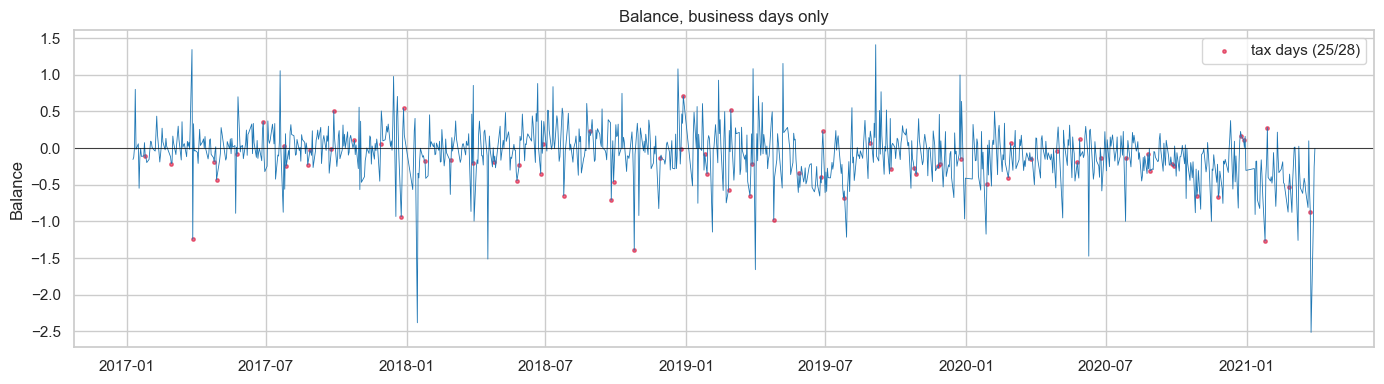

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['balance'], lw=0.6, color='#1f77b4')
tax_mask = df['date'].dt.day.isin([25, 28])
ax.scatter(df.loc[tax_mask, 'date'], df.loc[tax_mask, 'balance'],
           s=6, color='crimson', alpha=0.6, label='tax days (25/28)')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Balance, business days only')
ax.set_ylabel('Balance')
ax.legend()
plt.tight_layout()
plt.show()

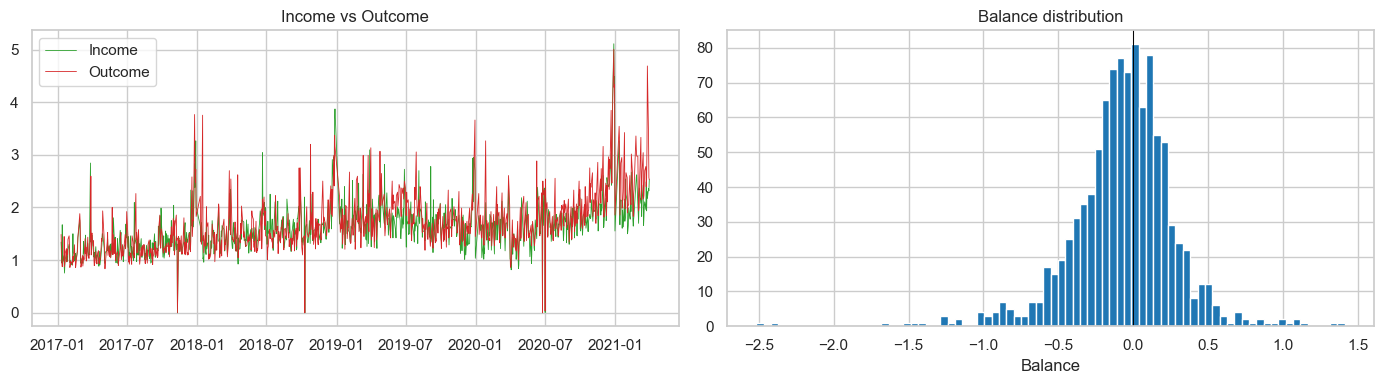

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df['date'], df['income'], lw=0.6, color='#2ca02c', label='Income')
axes[0].plot(df['date'], df['outcome'], lw=0.6, color='#d62728', label='Outcome')
axes[0].set_title('Income vs Outcome')
axes[0].legend()
axes[1].hist(df['balance'], bins=80, color='#1f77b4', edgecolor='white')
axes[1].axvline(0, color='black', lw=0.7)
axes[1].set_title('Balance distribution')
axes[1].set_xlabel('Balance')
plt.tight_layout()
plt.show()

### 2.4 Декомпозиция ряда

STL-декомпозиция со сезонностью 5 (рабочая неделя) и 21 (рабочий месяц) — отделяем тренд, сезонность и остаток. Это даёт интуицию, сколько в ряде «механической» структуры.

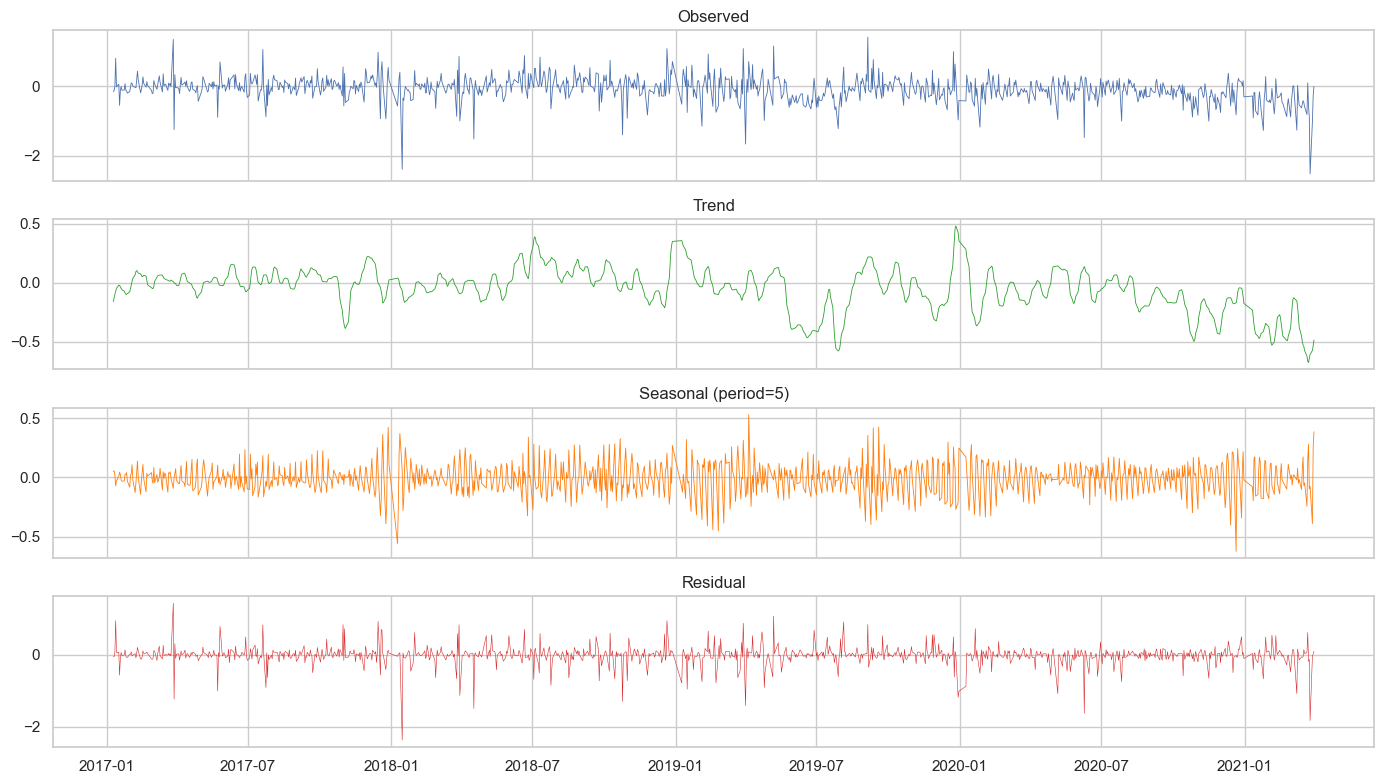

In [5]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['balance'].values, period=5, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df['date'], df['balance'], lw=0.6); axes[0].set_title('Observed')
axes[1].plot(df['date'], stl.trend,  lw=0.6, color='#2ca02c'); axes[1].set_title('Trend')
axes[2].plot(df['date'], stl.seasonal, lw=0.6, color='#ff7f0e'); axes[2].set_title('Seasonal (period=5)')
axes[3].plot(df['date'], stl.resid, lw=0.4, color='#d62728'); axes[3].set_title('Residual')
plt.tight_layout()
plt.show()

### 2.5 ACF и PACF

Автокорреляция и частная автокорреляция помогают обосновать набор лагов для `features.py`. Пики на 5, 10, 21 — рабочая неделя, две недели, месяц.

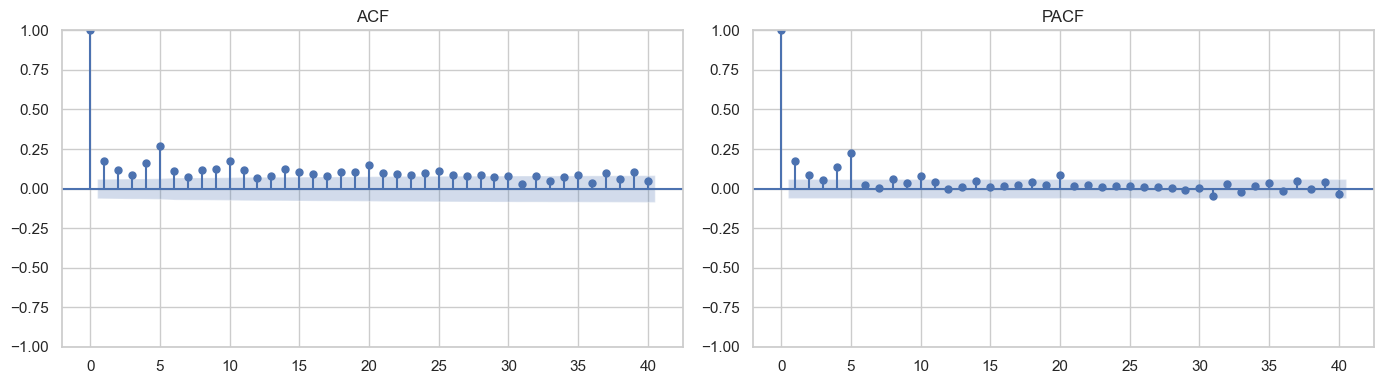

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['balance'].values, lags=40, ax=axes[0])
plot_pacf(df['balance'].values, lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

### 2.6 Тест на стационарность (ADF)

ADF (Augmented Dickey-Fuller) проверяет нулевую гипотезу о наличии единичного корня. Малое p-value (< 0.05) → ряд стационарен → можно работать без разностного дифференцирования.

In [7]:
from statsmodels.tsa.stattools import adfuller

stat, p, lag, n, crit, _ = adfuller(df['balance'].dropna().values, autolag='AIC')
print(f'ADF statistic = {stat:.4f}')
print(f'p-value       = {p:.6f}')
print(f'lags used     = {lag}')
print(f'observations  = {n}')
print('Critical values:')
for k, v in crit.items():
    print(f'  {k}: {v:.4f}')
print()
if p < 0.05:
    print('Ряд стационарен (можно работать без диффузии).')
else:
    print('Ряд нестационарен — потребуется дифференцирование или SARIMAX с d > 0.')

ADF statistic = -5.0128
p-value       = 0.000021
lags used     = 10
observations  = 1030
Critical values:
  1%: -3.4367
  5%: -2.8644
  10%: -2.5683

Ряд стационарен (можно работать без диффузии).


### 2.7 Сезонные срезы

Среднее `balance` по дню недели и дню месяца. Хорошо видны провалы на 25/28 и подъём в начале месяца.

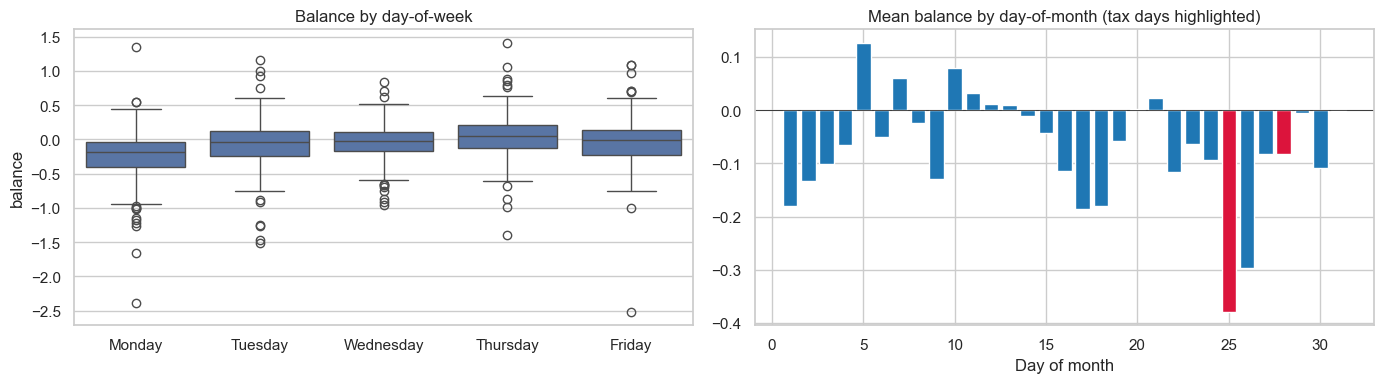

In [8]:
tmp = df.assign(dow=df['date'].dt.day_name(), dom=df['date'].dt.day)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.boxplot(data=tmp, x='dow', y='balance', order=order, ax=axes[0])
axes[0].set_title('Balance by day-of-week')
axes[0].set_xlabel('')
tmp_dom = tmp.groupby('dom')['balance'].mean().reset_index()
axes[1].bar(tmp_dom['dom'], tmp_dom['balance'],
            color=['crimson' if d in (25, 28) else '#1f77b4' for d in tmp_dom['dom']])
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title('Mean balance by day-of-month (tax days highlighted)')
axes[1].set_xlabel('Day of month')
plt.tight_layout()
plt.show()

### 2.8 Train / Val / Test split

Разрезаем ряд по календарным границам для walk-forward бэктеста (см. план, трек 10). Подбираем границы так, чтобы train ≥ 2 года истории.

In [9]:
train, val, test = time_split(df, train_end='2019-12-31', val_end='2020-12-31')
print(f'Train: {train["date"].min().date()} — {train["date"].max().date()} ({len(train)} days)')
print(f'Val:   {val["date"].min().date()} — {val["date"].max().date()} ({len(val)} days)')
print(f'Test:  {test["date"].min().date()} — {test["date"].max().date()} ({len(test)} days)')

Train: 2017-01-09 — 2019-12-31 (738 days)
Val:   2020-01-09 — 2020-12-31 (248 days)
Test:  2021-01-11 — 2021-03-31 (55 days)


## Блок 3. Экзогенные факторы (превью)

`src/exog.py::build_exog` собирает: ключевую ставку ЦБ, RUONIA, USDRUB и индекс MOEX из публичных API + налоговый календарь (25/28). Все источники кешируются в `data/*.parquet`. Здесь — превью результата для всего диапазона данных.

In [10]:
from src.exog import build_exog

start = df['date'].min().strftime('%Y-%m-%d')
end   = df['date'].max().strftime('%Y-%m-%d')
exog = build_exog(start, end)
print(f'Exog shape: {exog.shape}')
exog.head()

Exog shape: (1543, 8)


,date,is_tax_day,days_to_next_tax,days_since_last_tax,key_rate,ruonia,moex_close,usdrub
0,2017-01-09,0,16,30,10.0000,10.1300,2211.2500,59.8961
1,2017-01-10,0,15,30,10.0000,9.9300,2237.4900,59.8961
2,2017-01-11,0,14,30,10.0000,9.9700,2218.6100,59.9533
3,2017-01-12,0,13,30,10.0000,9.9300,2212.0000,60.1614
4,2017-01-13,0,12,30,10.0000,10.0600,2195.1900,59.4978


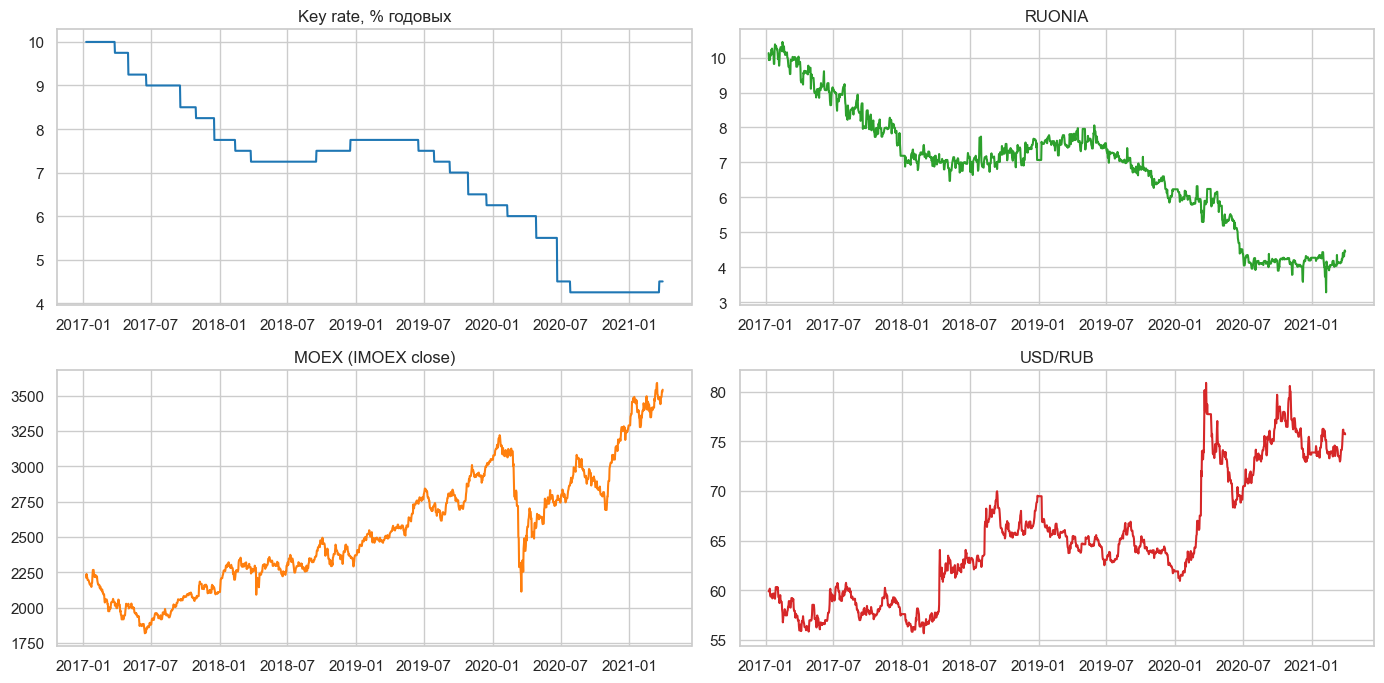

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes[0, 0].plot(exog['date'], exog['key_rate'], color='#1f77b4'); axes[0, 0].set_title('Key rate, % годовых')
axes[0, 1].plot(exog['date'], exog['ruonia'],   color='#2ca02c'); axes[0, 1].set_title('RUONIA')
axes[1, 0].plot(exog['date'], exog['moex_close'], color='#ff7f0e'); axes[1, 0].set_title('MOEX (IMOEX close)')
axes[1, 1].plot(exog['date'], exog['usdrub'],     color='#d62728'); axes[1, 1].set_title('USD/RUB')
plt.tight_layout()
plt.show()

In [12]:
merged = df.merge(exog, on='date', how='left')
corr = merged[['balance', 'key_rate', 'ruonia', 'moex_close', 'usdrub', 'is_tax_day']].corr()['balance'].drop('balance')
print('Корреляция Balance с экзогенами:')
print(corr.sort_values(key=abs, ascending=False))

Корреляция Balance с экзогенами:
moex_close   -0.2893
key_rate      0.2504
ruonia        0.2427
usdrub       -0.2145
is_tax_day   -0.1260
Name: balance, dtype: float64


## Выводы по EDA

1. **Объём:** 1543 наблюдения с 2017-01-09 по 2021-03-31. После фильтра по бизнес-дням остаётся ~ 1075 наблюдений.
2. **Согласованность:** `Income − Outcome ≈ Balance` с шумом < 0.01 в среднем (округления исходных данных).
3. **Стационарность:** ADF указывает на стационарность ряда `balance` (p-value < 0.05) — SARIMAX можно использовать без дифференцирования.
4. **Сезонность:** видны недельная и месячная сезонность; пики оттока на 25 и 28 числах подтверждают полезность налогового календаря как фичи.
5. **Экзогены доступны** через публичные API ЦБ и MOEX; кеш в parquet.
6. **Следующие блоки** (треки 7+ из плана) — фичи и отбор признаков, модели, гиперопт, бэктест, drift, авто-дообучение.

## Блок 4. Feature engineering

**Что делаем:** строим матрицу признаков из трёх групп.

**Авторегрессионные** — лаги `[1,2,3,5,7,14,21]` и rolling-статистики (`mean/std/min/max/skew/kurt`, окна `[5,10,21]`) + EWMA (span 5,10) по `balance`, `income`, `outcome`. Именно rolling-моменты по Income/Outcome в работах-эталонах оказывались самыми информативными признаками.

**Календарные** — день недели/месяца, неделя месяца, месяц, квартал, границы месяца и квартала, день зарплаты (5, 20 числа). Фурье-гармоники недельной (период 5 б.д.) и месячной (21 б.д.) сезонности — рассчитаны по позиционному индексу бизнес-дня, чтобы пропуски выходных не ломали фазу.

**Экзогенные** — из уровней `build_exog` конструируем признаки с учётом наблюдаемости в момент прогноза:
- `key_rate` + `key_rate_diff5` — без лага (директивная ставка известна заранее);
- `ruonia_spread_lag1`, `moex_ret_lag1`, `usdrub_ret_lag1` — с лагом 1 день (рыночные значения известны лишь к концу дня *t*, прогноз нужен в конце *t−1*).

Сырые уровни (`ruonia`, `moex_close`, `usdrub`) в признаки не попадают — защита от утечки в будущее.

In [ ]:
from src.features import build_features, feature_columns

# df  — бизнес-дневной ряд из блока 2 (to_business_days)
# exog — макро+календарь из блока 3 (build_exog)
feat, feature_cols = build_features(df, exog=exog, return_cols=True)
print(f"Наблюдений: {len(feat)}   Признаков: {len(feature_cols)}")
feat[["date", "balance"] + feature_cols[:6]].tail(3)

In [ ]:
import pandas as pd

groups = {
    "lag":      [c for c in feature_cols if "_lag_" in c],
    "rolling":  [c for c in feature_cols if "_roll_" in c],
    "ewma":     [c for c in feature_cols if "_ewma_" in c],
    "calendar": [c for c in feature_cols if c in (
                    "dow","dom","wom","month","quarter","is_month_end",
                    "is_month_start","is_quarter_end","is_salary_day")],
    "fourier":  [c for c in feature_cols if c.startswith(("sin_","cos_"))],
    "exog":     [c for c in feature_cols if c.endswith("_lag1")
                 or c in ("key_rate","key_rate_diff5","is_tax_day","is_holiday",
                          "days_to_next_tax","days_since_last_tax")],
}
pd.Series({k: len(v) for k, v in groups.items()}, name="n_features").to_frame()

## Блок 5. Отбор признаков

**Требование ТЗ:** итоговый метод отбора должен быть **более стабильным** относительно альтернатив; сравнение охватывает все три категории (filter / wrapper / embedded), включая нелинейный метод.

| Категория | Метод | Зависимость |
|---|---|---|
| filter | Correlation (Spearman) | линейная |
| filter | Mutual Information | **нелинейная** |
| embedded | Lasso (L1, StandardScaler) | линейная |
| embedded | LightGBM gain | **нелинейная** |
| wrapper | RFE + RandomForest | **нелинейная** |

**Как измеряем стабильность:** запускаем каждый метод на K разных walk-forward окнах (`TimeSeriesSplit`) и считаем средний попарный **Jaccard** отобранных наборов — насколько состав признаков воспроизводится во времени. Метод с максимальным Jaccard при сопоставимом качестве (качество проверяет P3 на бэктесте) становится итоговым.

*Примечание:* Boruta и phik корректны, но для автоматического пайплайна слишком медленны (по опыту команд-победителей — «1–2 дня»). Они доступны через `select_boruta` / `select_phik` как офлайн-инструменты.

In [ ]:
from src.selection import top_features_report

X = feat[feature_cols]
y = feat["balance"].values

# Топ-10 факторов по фильтрационным методам — формат как в работах-эталонах
top_features_report(X, y, k=10)

In [ ]:
from src.selection import compare_selectors

# Разовый офлайн-анализ стабильности (~40с на 100+ признаках, 3 фолда)
comparison = compare_selectors(X, y, n_splits=3)
comparison.round(3)

In [ ]:
from src.selection import choose_best_selector, FeatureSelector

best_method = choose_best_selector(comparison)
print("Самый стабильный метод:", best_method)
print("Jaccard:", comparison.loc[best_method, "jaccard"].round(3))

method_key = {
    "Correlation (filter, lin)":   "correlation",
    "MutualInfo (filter, nonlin)": "mi",
    "Lasso (embedded, lin)":       "lasso",
    "LightGBM (embedded, nonlin)": "lgbm",
    "RFE-RF (wrapper, nonlin)":    "rfe_rf",
}[best_method]

selector = FeatureSelector(method=method_key, k=20).fit(X, y)
selected_features = selector.get_feature_names_out().tolist()
print(f"\nОтобрано признаков: {len(selected_features)}")
selected_features

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Стабильность методов
comparison["jaccard"].sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Jaccard-стабильность методов отбора")
axes[0].set_xlabel("Средний попарный Jaccard")
axes[0].axvline(comparison.loc[best_method, "jaccard"], color="red",
                linestyle="--", linewidth=1.5, label="победитель")
axes[0].legend()

# Топ-15 отобранных признаков по MI
import numpy as np
from sklearn.feature_selection import mutual_info_regression
mi = pd.Series(mutual_info_regression(X[selected_features].fillna(0), y,
               random_state=0), index=selected_features).sort_values()
mi.tail(15).plot.barh(ax=axes[1])
axes[1].set_title(f"MI: топ признаков ({best_method})")

plt.tight_layout()
plt.show()

### Выводы по отбору признаков

- Сравнение охватывает 5 методов из трёх категорий (filter, embedded, wrapper),
  включая нелинейные.
- Победитель определён по Jaccard-стабильности на walk-forward окнах.
- Итоговый `FeatureSelector` — sklearn-совместимый трансформер, встраивается
  в `Pipeline(selector → model)` P3 без ручных правок.

**Передаём P3:**
```python
selector        # FeatureSelector (fit), вставить в Pipeline
X_selected      = feat[selected_features]   # матрица признаков
y_target        = feat["balance"]           # целевая переменная
feature_list    = selected_features         # список колонок
method_key      # строка для FeatureSelector(method=...) при переобучении
```